**แปลง X_train และ X_test เป็น Dataframe เนื่องจาก X_train และ X_test ที่ได้จาก transform() จะเป็น Numpy Array**

**แปลง X_train และ X_test เป็น Dataframe เนื่องจาก X_train และ X_test ที่ได้จาก transform() จะเป็น Numpy Array**

In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, train_test_split

**แปลง X_train และ X_test เป็น Dataframe เนื่องจาก X_train และ X_test ที่ได้จาก transform() จะเป็น Numpy Array**

# Airline Passenger Satisfaction

- **Gender**: Gender of the passengers (Female, Male)

- **Customer Type**: The customer type (Loyal customer, disloyal customer)

- **Age**: The actual age of the passengers

- **Type of Travel**: Purpose of the flight of the passengers (Personal Travel, Business Travel)

- **Class**: Travel class in the plane of the passengers (Business, Eco, Eco Plus)

- **Flight distance**: The flight distance of this journey

- **Inflight wifi service**: Satisfaction level of the inflight wifi service (0:Not Applicable;1-5)

- **Departure/Arrival time convenient**: Satisfaction level of Departure/Arrival time convenient

- **Ease of Online booking**: Satisfaction level of online booking

- **Gate location**: Satisfaction level of Gate location

- **Food and drink**: Satisfaction level of Food and drink

- **Online boarding**: Satisfaction level of online boarding

- **Seat comfort**: Satisfaction level of Seat comfort

- **Inflight entertainment**: Satisfaction level of inflight entertainment

- **On-board service**: Satisfaction level of On-board service

- **Leg room service**: Satisfaction level of Leg room service

- **Baggage handling**: Satisfaction level of baggage handling

- **Check-in service**: Satisfaction level of Check-in service

- **Inflight service**: Satisfaction level of inflight service

- **Cleanliness**: Satisfaction level of Cleanliness

- **Departure Delay in Minutes**: Minutes delayed when departure

- **Arrival Delay in Minutes**: Minutes delayed when Arrival

- **Satisfaction**: Airline satisfaction level(Satisfaction, neutral or dissatisfaction)

# Read data

In [84]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [85]:
df = pd.read_csv('data/airlines.csv')
df.shape

(64940, 23)

In [86]:
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,69,Personal Travel,Eco,762,3,3,3,4,...,2,2,3,2,2,2,2,0,0.0,neutral or dissatisfied
1,Female,Loyal Customer,37,Business travel,Eco,102,4,5,5,5,...,4,4,4,1,4,2,4,0,0.0,neutral or dissatisfied
2,Male,disloyal Customer,26,Business travel,Business,2475,1,2,2,1,...,4,3,5,5,1,3,1,0,6.0,neutral or dissatisfied
3,Female,Loyal Customer,47,Personal Travel,Eco,628,2,4,2,2,...,5,5,2,2,5,5,5,0,0.0,neutral or dissatisfied
4,Male,disloyal Customer,27,Business travel,Eco,1034,2,2,2,1,...,3,1,4,2,2,3,2,160,134.0,neutral or dissatisfied


**ตรวจสอบ categorical ว่าประกอบไปด้วยอะค่าไรบ้าง**

In [87]:
# your code here
print(df['Gender'].unique())
print(df['Customer Type'].unique())
print(df['Type of Travel'].unique())
print(df['Class'].unique())


['Female' 'Male']
['Loyal Customer' 'disloyal Customer']
['Personal Travel' 'Business travel']
['Eco' 'Business' 'Eco Plus']


**EX: แปลง categorical เป็น numerical**
```
Gender: 'Male':1, 'Female':0
Customer Type: 'Loyal Customer':1, 'disloyal Customer':0
Type of Travel: 'Business travel':1, 'Personal Travel': 0
satisfaction: 'satisfied':1, 'neutral or dissatisfied':0
```

In [88]:
df['Gender'] = df["Gender"].replace({'Male':1, 'Female':0})
df['Customer Type'] = df["Customer Type"].replace({'Loyal Customer':1, 'disloyal Customer':0})
df['Type of Travel'] = df["Type of Travel"].replace({'Business travel':1, 'Personal Travel': 0})

df['satisfaction'] = df["satisfaction"].replace({'satisfied':1, 'neutral or dissatisfied':0})

df.head()

/tmp/ipython-input-1001162565.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df["Gender"].replace({'Male':1, 'Female':0})
/tmp/ipython-input-1001162565.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Customer Type'] = df["Customer Type"].replace({'Loyal Customer':1, 'disloyal Customer':0})
/tmp/ipython-input-1001162565.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,1,69,0,Eco,762,3,3,3,4,...,2,2,3,2,2,2,2,0,0.0,0
1,0,1,37,1,Eco,102,4,5,5,5,...,4,4,4,1,4,2,4,0,0.0,0
2,1,0,26,1,Business,2475,1,2,2,1,...,4,3,5,5,1,3,1,0,6.0,0
3,0,1,47,0,Eco,628,2,4,2,2,...,5,5,2,2,5,5,5,0,0.0,0
4,1,0,27,1,Eco,1034,2,2,2,1,...,3,1,4,2,2,3,2,160,134.0,0


In [89]:

# your code here
def one_hot_encode(_dataframe, list_of_columns_to_one_hot_encode):
    for column in list_of_columns_to_one_hot_encode:
        # one-hot-encode this column
        one_hot_encoded_values = pd.get_dummies(_dataframe[column], prefix=column)

        # join the one-hot-encoded values with original dataframe
        _dataframe = pd.concat([_dataframe, one_hot_encoded_values], axis=1)

        # drop the original column, we don't need it anymore
        _dataframe.drop([column], axis=1, inplace=True)

    return _dataframe
categorical_columns = df.select_dtypes(exclude=['int', 'float']).columns
print(categorical_columns)
df = one_hot_encode(df, categorical_columns)
df.head()

Index(['Class'], dtype='object')


,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
0,0,1,69,0,762,3,3,3,4,3,...,2,2,2,2,0,0.0,0,False,True,False
1,0,1,37,1,102,4,5,5,5,4,...,1,4,2,4,0,0.0,0,False,True,False
2,1,0,26,1,2475,1,2,2,1,2,...,5,1,3,1,0,6.0,0,True,False,False
3,0,1,47,0,628,2,4,2,2,2,...,2,5,5,5,0,0.0,0,False,True,False
4,1,0,27,1,1034,2,2,2,1,2,...,2,2,3,2,160,134.0,0,False,True,False


In [41]:
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,1,69,0,0,762,3,3,3,4,...,2,2,3,2,2,2,2,0,0.0,0
1,0,1,37,1,0,102,4,5,5,5,...,4,4,4,1,4,2,4,0,0.0,0
2,1,0,26,1,1,2475,1,2,2,1,...,4,3,5,5,1,3,1,0,6.0,0
3,0,1,47,0,0,628,2,4,2,2,...,5,5,2,2,5,5,5,0,0.0,0
4,1,0,27,1,0,1034,2,2,2,1,...,3,1,4,2,2,3,2,160,134.0,0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64940 entries, 0 to 64939
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             64940 non-null  int64  
 1   Customer Type                      64940 non-null  int64  
 2   Age                                64940 non-null  int64  
 3   Type of Travel                     64940 non-null  int64  
 4   Flight Distance                    64940 non-null  int64  
 5   Inflight wifi service              64940 non-null  int64  
 6   Departure/Arrival time convenient  64940 non-null  int64  
 7   Ease of Online booking             64940 non-null  int64  
 8   Gate location                      64940 non-null  int64  
 9   Food and drink                     64940 non-null  int64  
 10  Online boarding                    64940 non-null  int64  
 11  Seat comfort                       64940 non-null  int

In [54]:
df.head()

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
0,0,1,69,0,762,3,3,3,4,3,...,2,2,2,2,0,0.0,0,False,True,False
1,0,1,37,1,102,4,5,5,5,4,...,1,4,2,4,0,0.0,0,False,True,False
2,1,0,26,1,2475,1,2,2,1,2,...,5,1,3,1,0,6.0,0,True,False,False
3,0,1,47,0,628,2,4,2,2,2,...,2,5,5,5,0,0.0,0,False,True,False
4,1,0,27,1,1034,2,2,2,1,2,...,2,2,3,2,160,134.0,0,False,True,False


**EX: ทำ ont-hot encoding สำหรับ `class`**

In [90]:
# your code here
df['Class_Business'] = df["Class_Business"].replace({True:1, False:0})
df['Class_Eco'] = df["Class_Eco"].replace({True:1, False:0})
df['Class_Eco Plus'] = df["Class_Eco Plus"].replace({True:1, False:0})

/tmp/ipython-input-2987766649.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Class_Business'] = df["Class_Business"].replace({True:1, False:0})
/tmp/ipython-input-2987766649.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Class_Eco'] = df["Class_Eco"].replace({True:1, False:0})
/tmp/ipython-input-2987766649.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the fut

In [63]:
df.head()

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
0,0,1,69,0,762,3,3,3,4,3,...,2,2,2,2,0,0.0,0,0,1,0
1,0,1,37,1,102,4,5,5,5,4,...,1,4,2,4,0,0.0,0,0,1,0
2,1,0,26,1,2475,1,2,2,1,2,...,5,1,3,1,0,6.0,0,1,0,0
3,0,1,47,0,628,2,4,2,2,2,...,2,5,5,5,0,0.0,0,0,1,0
4,1,0,27,1,1034,2,2,2,1,2,...,2,2,3,2,160,134.0,0,0,1,0


In [56]:
df.describe()

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
count,64940.000000,64940.000000,64940.000000,64940.000000,64940.000000,64940.000000,64940.000000,64940.000000,64940.000000,64940.000000,...,64940.000000,64940.000000,64940.000000,64940.000000,64940.000000,64739.000000,64940.000000,64940.000000,64940.00000,64940.000000
mean,0.491146,0.817247,39.351971,0.689483,1186.627826,2.730043,3.052002,2.752294,2.969988,3.201694,...,3.637142,3.304435,3.645042,3.283385,14.741207,15.146898,0.434463,1.522374,1.55077,1.926856
std,0.499925,0.386467,15.107504,0.462709,994.375188,1.327983,1.523988,1.400643,1.278438,1.331305,...,1.178829,1.266972,1.175566,1.315244,38.662790,39.102512,0.495690,0.499503,0.49742,0.260375
min,0.000000,0.000000,7.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.00000,1.000000
25%,0.000000,1.000000,27.000000,0.000000,413.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.00000,2.000000
50%,0.000000,1.000000,40.000000,1.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000,2.000000,2.00000,2.000000
75%,1.000000,1.000000,51.000000,1.000000,1739.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000,1.000000,2.000000,2.00000,2.000000
max,1.000000,1.000000,85.000000,1.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000,1.000000,2.000000,2.00000,2.000000


**EX: ตรวจสอบว่าข้อมูลมีค่าว่างหรือไม่**

In [91]:
# your code here
df.isna().sum()


,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0
Food and drink,0


**ทำการ drop แถวข้อมูลที่มีค่า NaN - inplace = True**

In [92]:
# your code here
df.dropna(inplace=True)

In [93]:
# ตรวจสอบดูอีกรอบว่ายังมี null หรือไม่
df.isna().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0
Food and drink,0


**ดูความสัมพันธ์ระหว่างตัวแปร Spearman's Correlation**

<Axes: >

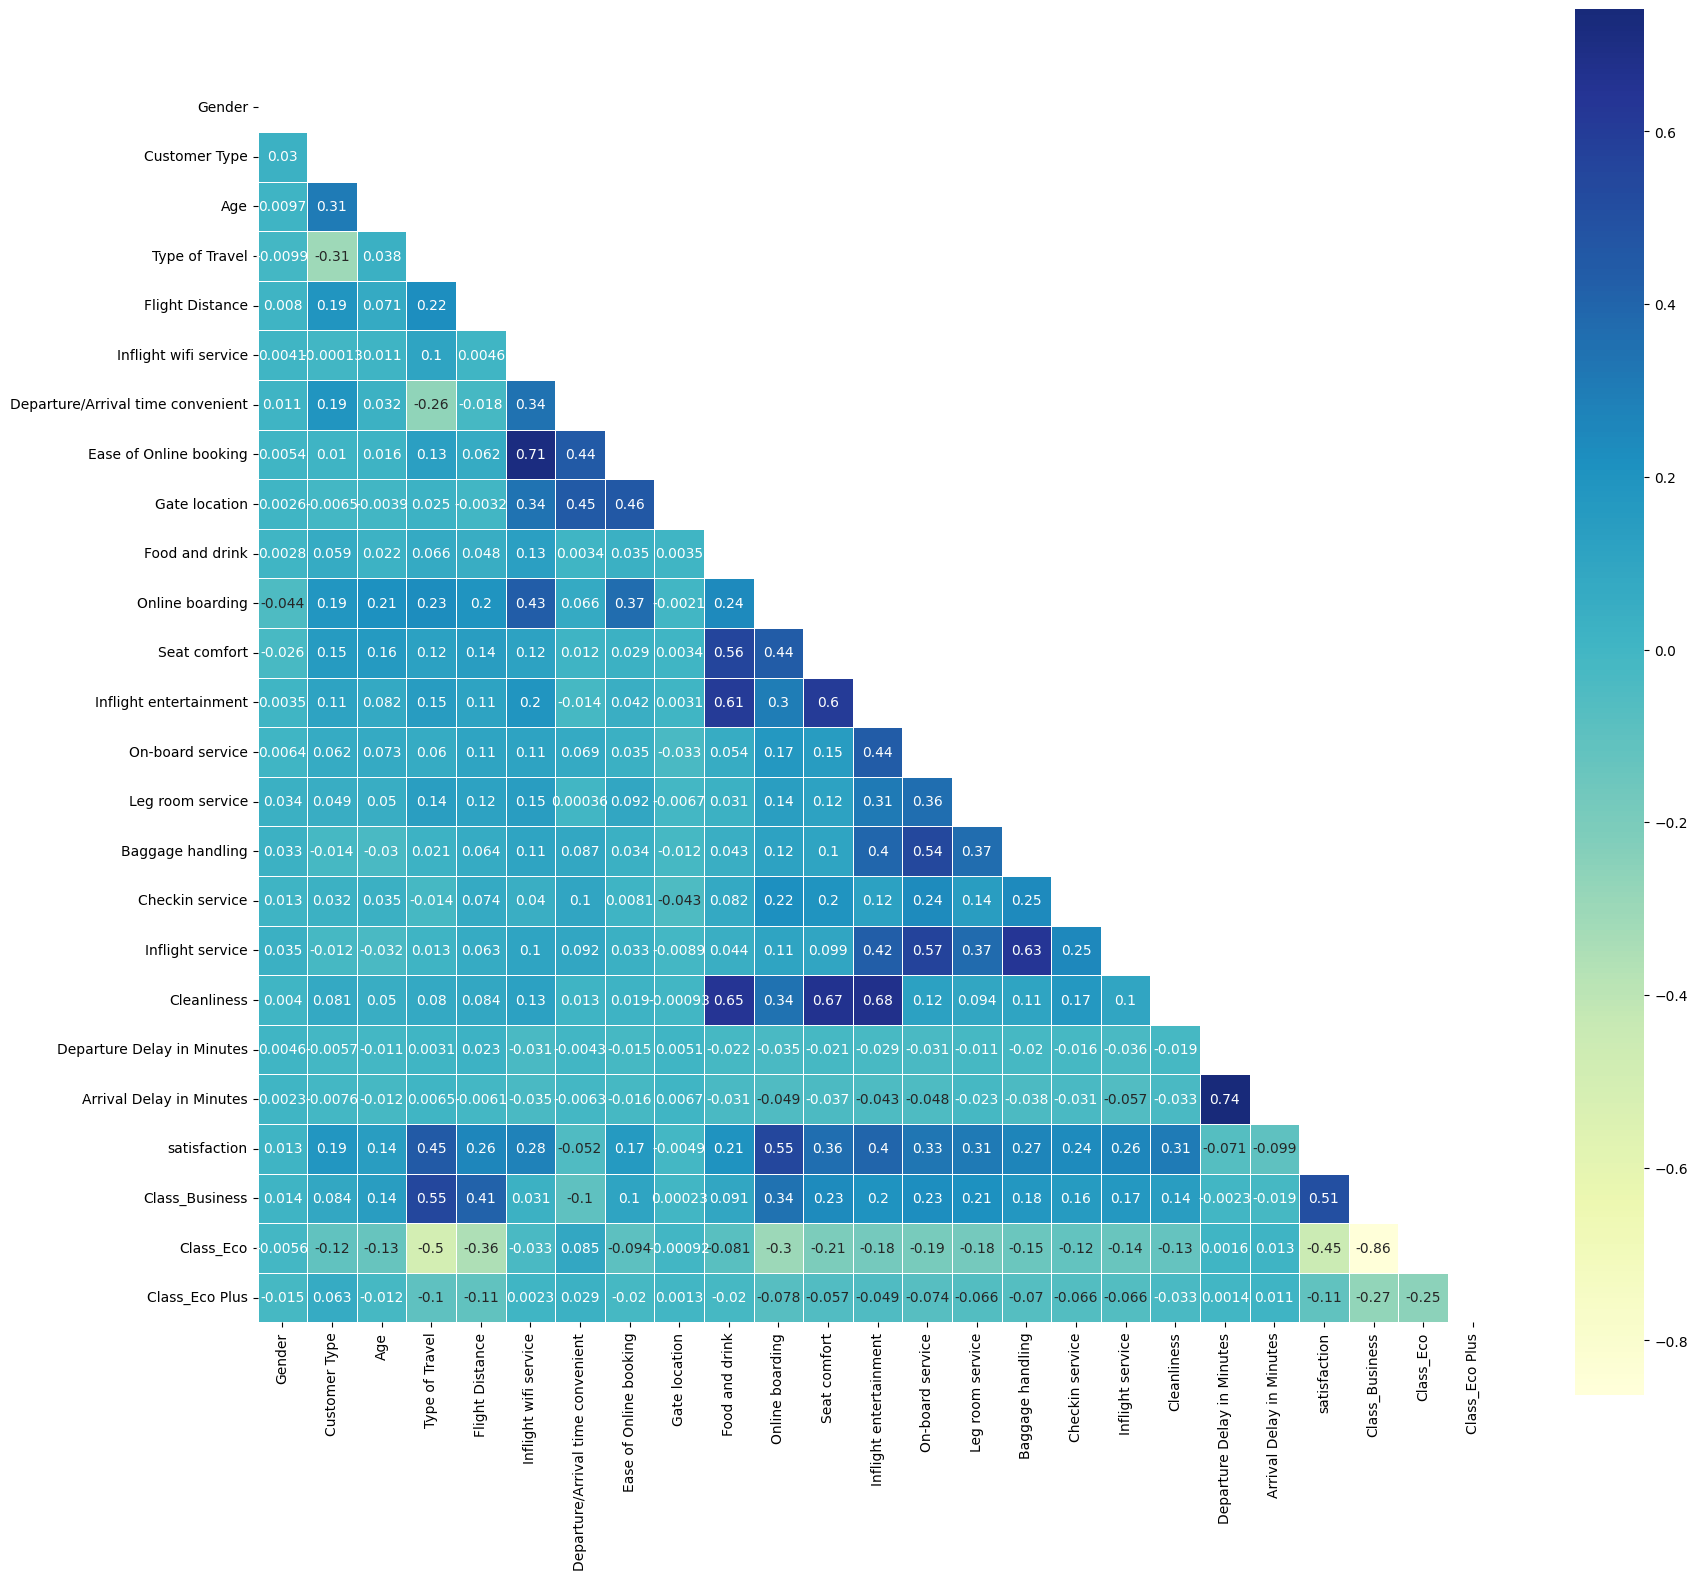

In [94]:
corr = df.corr(method='spearman')
# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(20, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, annot = True, mask=mask, cmap="YlGnBu", center=0,
            square=True, linewidths=.5)

# Train Test Split

**EX: กำหนดตัวแปรต้น (X) และตัวแปรตาม (y)**

In [98]:
# your code here
X_df = df.drop('satisfaction', axis=1)
y = df['satisfaction']

**EX: สร้าง Training Data และ Testing Data โดยกำหนด `test_size=0.2` และ `random_state=10`**

In [99]:
# your code here
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=10)

**EX: Scale ข้อมูลโดย ทำ min-max normailzation**

In [100]:
from re import X
from sklearn.preprocessing import MinMaxScaler
X_train = MinMaxScaler().fit_transform(X_train)
X_test = MinMaxScaler().fit_transform(X_test)

**แปลง X_train และ X_test เป็น Dataframe เนื่องจาก X_train และ X_test ที่ได้จาก transform() จะเป็น Numpy Array**

In [101]:
X_train = pd.DataFrame(X_train, columns=X_df.columns)
X_test = pd.DataFrame(X_test, columns=X_df.columns)

<AxesSubplot:title={'center':'Train target'}>

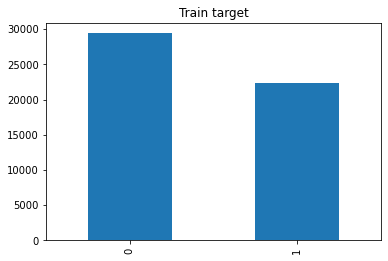

In [ ]:
plt.title('Train target')
y_train.value_counts().plot(kind='bar')

<Axes: title={'center': 'Test target'}, xlabel='satisfaction'>

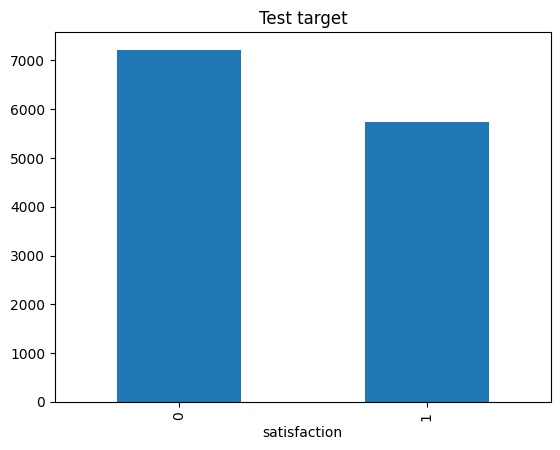

In [102]:
plt.title('Test target')
y_test.value_counts().plot(kind='bar')

In [103]:
X_train.head()

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Class_Business,Class_Eco,Class_Eco Plus
0,1.0,1.0,0.256410,0.0,0.192246,0.6,0.8,0.6,0.2,0.2,...,0.4,1.00,0.8,1.0,0.2,0.000000,0.000000,0.0,1.0,0.0
1,0.0,1.0,0.512821,1.0,0.203958,0.4,0.4,0.4,0.4,0.2,...,0.4,0.25,0.4,0.4,0.4,0.002513,0.012626,0.0,1.0,0.0
2,1.0,1.0,0.474359,1.0,0.760097,1.0,1.0,1.0,1.0,0.6,...,0.8,0.75,0.8,0.8,0.6,0.000000,0.000000,1.0,0.0,0.0
3,1.0,1.0,0.025641,0.0,0.202746,0.4,0.8,0.4,0.6,1.0,...,0.6,0.75,1.0,0.8,1.0,0.007538,0.000000,0.0,1.0,0.0
4,0.0,1.0,0.435897,1.0,0.414580,0.2,0.2,0.2,0.2,1.0,...,1.0,0.75,0.8,0.8,1.0,0.000000,0.000000,1.0,0.0,0.0


**EX: Plot histogram สำหรับทุก features**

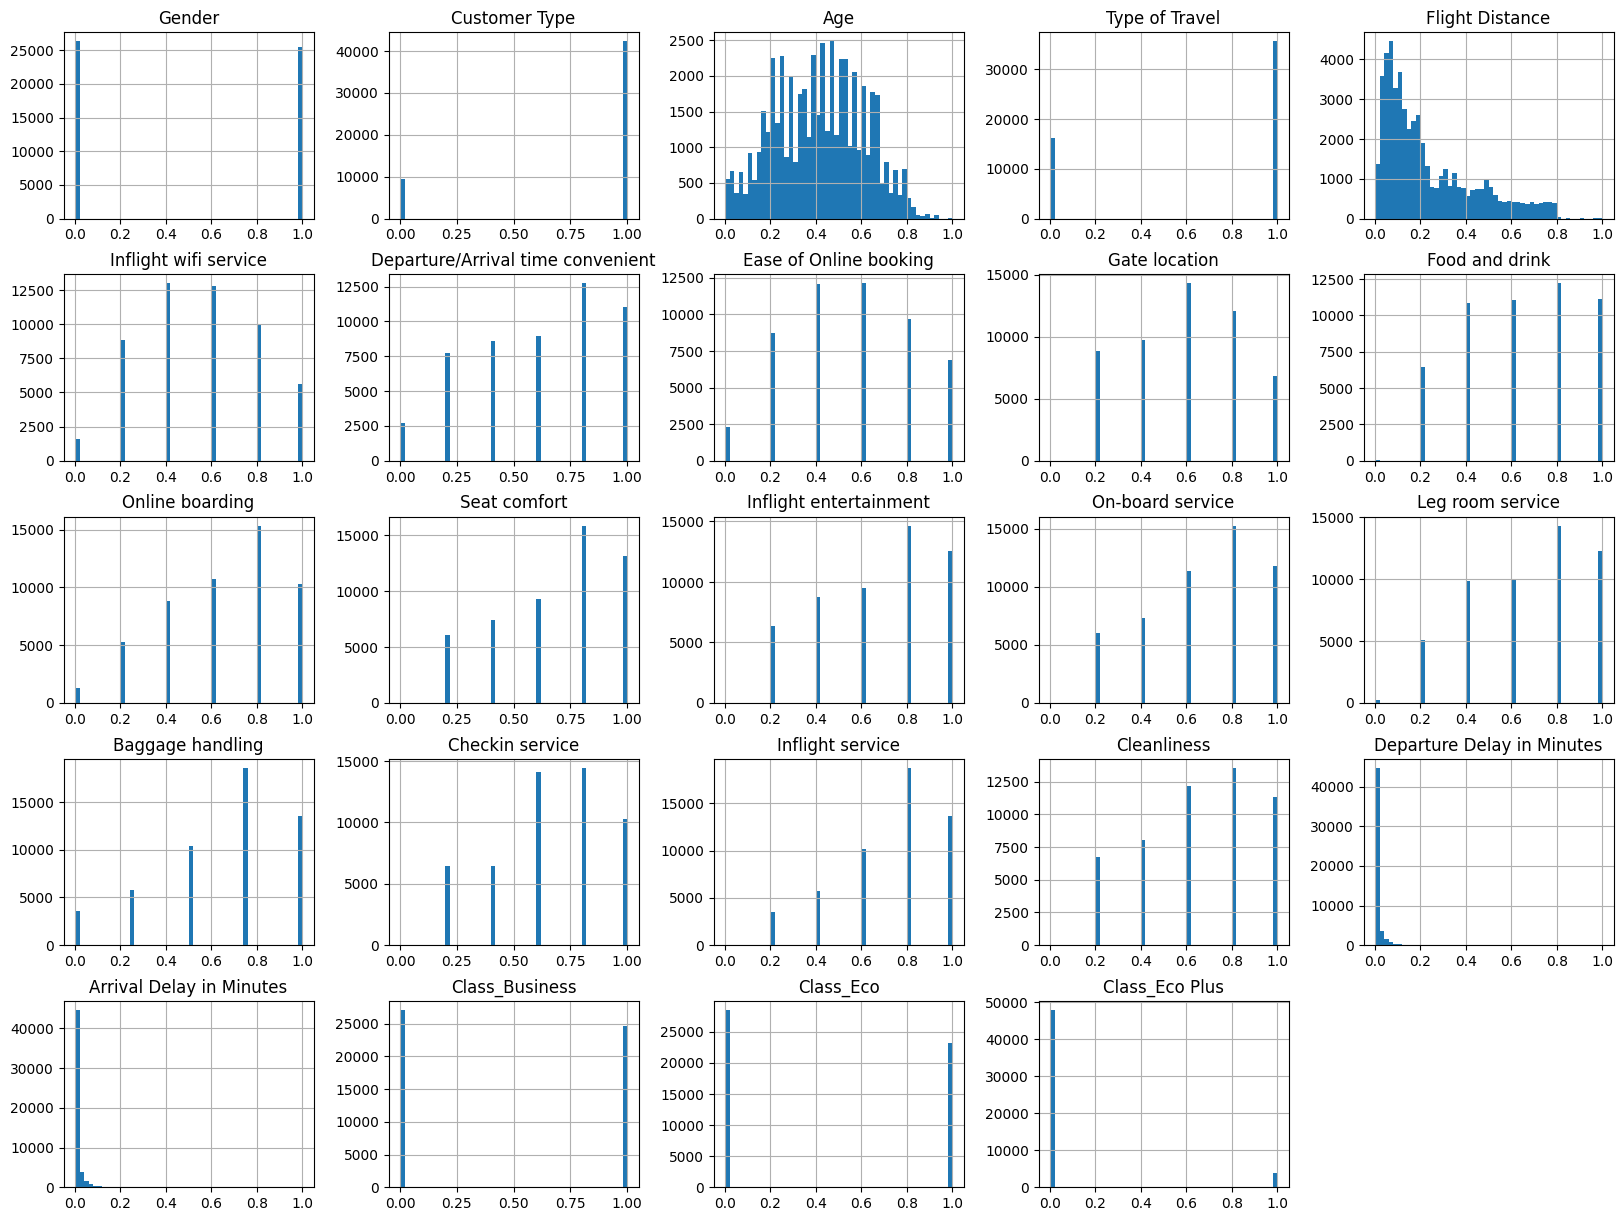

In [104]:
# your code here
import matplotlib.pyplot as plt

X_train.hist(bins=50, figsize=(20,15))
plt.show()

***

# Logistic regression

**EX: Train model Ligistic Regression โดยกำหนด solver='liblinear'**

In [108]:
# Create model named 'clf_lr' - use solver='liblinear'
# your code here
from sklearn.linear_model import LogisticRegression
clf_lr = LogisticRegression(solver='liblinear')

# Train model

clf_lr.fit(X_train, y_train)

# Predict named 'lr_y_pred'
lr_y_pred = clf_lr.predict(X_test)


**EX: คำนวณค่า Accuracy, AUC ROC, แสดง Classification Report**

In [ ]:
# Accuracy score & classification report
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Get accuracy score


0.8721810318195861

In [ ]:
# Get ROC AUC


0.8682821128669639

In [ ]:
# Classification report


              precision    recall  f1-score   support

           0       0.87      0.90      0.89      7216
           1       0.87      0.83      0.85      5732

    accuracy                           0.87     12948
   macro avg       0.87      0.87      0.87     12948
weighted avg       0.87      0.87      0.87     12948



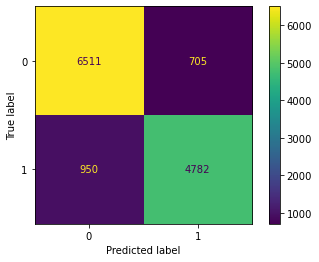

In [ ]:
# Draw confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf_lr, X_test, y_test)

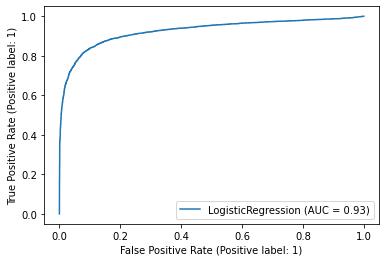

In [ ]:
# Draw ROC curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(clf_lr, X_test, y_test)

**EX: ตรวจสอบค่า Coefficient ของโมเดล และ plot bar chart**

In [ ]:
# Your code here


array([[ 0.06130304,  1.98499124, -0.67813062,  2.69655426, -0.14876972,
         1.9187061 , -0.63132848, -0.8176886 ,  0.16593568, -0.21044565,
         2.98828856,  0.29475626,  0.47937154,  1.46336553,  1.23579078,
         0.44845677,  1.72022218,  0.58394129,  1.11144152, -2.25517575,
        -4.61242752, -2.1711338 , -2.91796927, -3.0262404 ]])

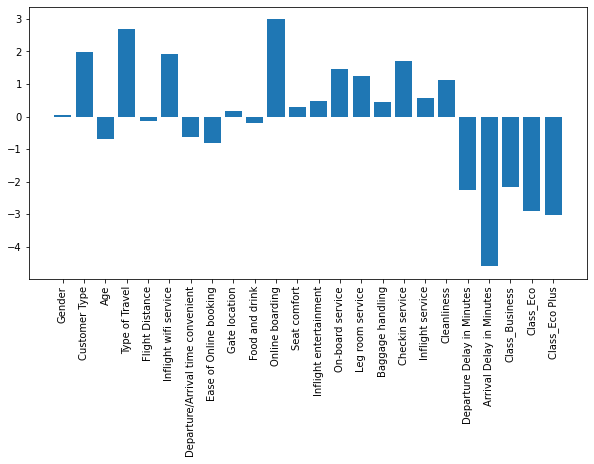

In [ ]:
# Plot a bar chart to display the coefficients


# Decission Tree

**EX: Train model Decision Tree**

In [ ]:
# Create model named 'clf_dt' กำหนด random_state=10, max_depth=5
# your code here


# Train model


# Predict named 'dt_y_pred'



**EX: คำนวณค่า Accuracy, AUC ROC, แสดง Classification Report**

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Get accuracy score


0.9023015137472968

In [ ]:
# Get roc auc score


0.899413453548987

In [ ]:
# Classification report

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      7216
           1       0.90      0.87      0.89      5732

    accuracy                           0.90     12948
   macro avg       0.90      0.90      0.90     12948
weighted avg       0.90      0.90      0.90     12948



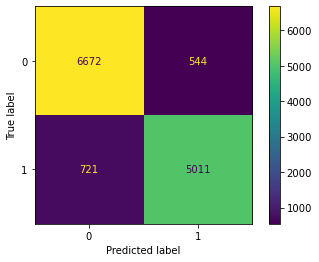

In [ ]:
# Draw Confusion matrix
ConfusionMatrixDisplay.from_estimator(clf_dt, X_test, y_test)

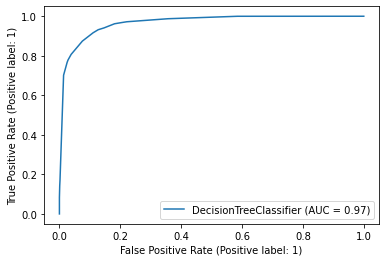

In [ ]:
# Plot ROC AUC curve
RocCurveDisplay.from_estimator(clf_dt, X_test, y_test)

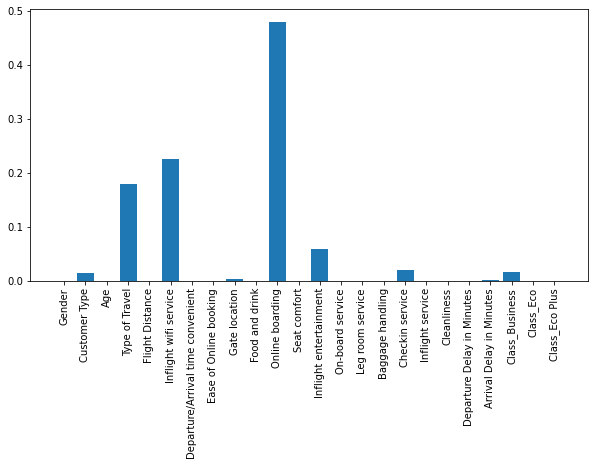

In [ ]:
# Plot a bar chart to display the coefficients
plt.figure(figsize=(10, 5))
plt.bar(X_train.columns, clf_dt.feature_importances_)
plt.xticks(rotation=90)
plt.show()

## Feature selection

**สร้าง model Desicion Tree โดยเลือกเฉพาะ feature: `Inflight wifi service`, `Type of Travel`, `Online boarding`, `Inflight entertainment` และ `Checkin service`**

In [ ]:
# กำหนดตัวแปร X_train2 และ X_test2 ที่เลือกเฉพาะ
# `Inflight wifi service`, `Type of Travel`, `Online boarding`, `Inflight entertainment` และ `Checkin service`
# your code here


In [ ]:
# Create model named 'clf_dt_2' กำหนด random_state=10


# Train model
# your code here


# Predict named 'dt_y_pred2'
# your code here


**EX: คำนวณค่า Accuracy, AUC ROC, แสดง Classification Report**

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
# your code here


Accuracy: 0.9168211306765524
ROC AUC: 0.9150232947485852
-----
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      7216
           1       0.91      0.90      0.91      5732

    accuracy                           0.92     12948
   macro avg       0.92      0.92      0.92     12948
weighted avg       0.92      0.92      0.92     12948



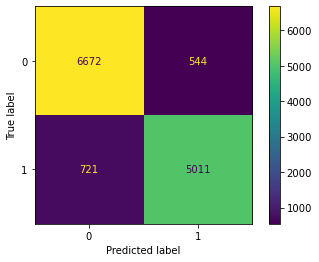

In [ ]:
# Draw Confusion matrix
ConfusionMatrixDisplay.from_estimator(clf_dt, X_test, y_test)

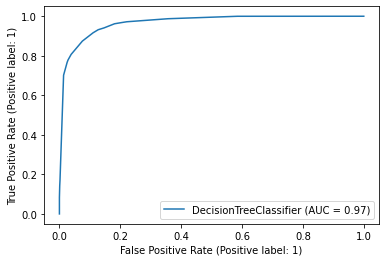

In [ ]:
# Plot ROC AUC curve
RocCurveDisplay.from_estimator(clf_dt, X_test, y_test)

# KNN

**EX: Train model KNN ด้วย `KNeighborsClassifier()` โดยกำหนด n_neighbors=5**

In [ ]:
# Create model named 'clf_knn'
# your code here


# Fit model
# your code here

# Predict named 'knn_y_pred'
# your code here


**EX: คำนวณค่า Accuracy, AUC ROC, แสดง Classification Report**

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
# your code here


Accuracy: 0.9263978992894656
ROC AUC: 0.9212832265431707
-----
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7216
           1       0.95      0.88      0.91      5732

    accuracy                           0.93     12948
   macro avg       0.93      0.92      0.92     12948
weighted avg       0.93      0.93      0.93     12948



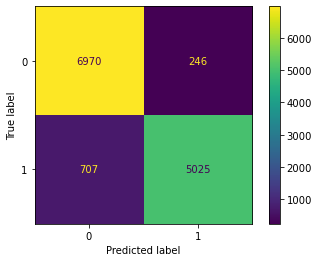

In [ ]:
# วาด Confusion matrix
ConfusionMatrixDisplay.from_estimator(clf_knn, X_test, y_test)


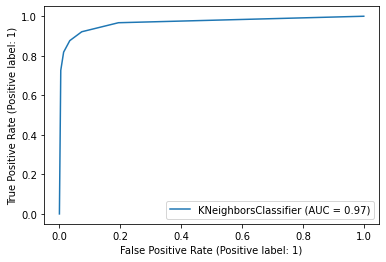

In [ ]:
# Plot ROC curve
RocCurveDisplay.from_estimator(clf_knn, X_test, y_test)

### Hyperparameters tuning

Hyperparameters ที่สำคัญสำหรับการ tune ของ KNN มีดังนี้

1. n_neighbors in [1 to 21]
2. metric in [‘euclidean’, ‘manhattan’, ‘minkowski’]
3. weights in [‘uniform’, ‘distance’]

ซึ่งจริงๆ มีอีกหลายตัวที่สามารถ tune ได้ [ref](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

**EX: ใช้ GridSearchCV ในการ tune KNN ดังนี้**

```python
grid = [
  {'n_neighbors': range(1,10), 'metric': ['euclidean', 'manhattan', 'minkowski']},
  {'n_neighbors': range(1,10), 'weights': ['uniform', 'distance']},
]
```

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# your code here

# fit with model named: "grid_result"


In [ ]:
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

**EX: เลือกค่า hyperparameter ที่ดีที่สุดมา train model โดยตั้งชื่อตัวแปรเป็น `clf_knn_tuned`**

In [ ]:
# Create model named 'clf_knn_tuned'
# your code here

# Fit model
# your code here

# Predict named 'knn_y_pred2'
# your code here


**EX: คำนวณค่า Accuracy, AUC ROC, แสดง Classification Report**

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
# your code here


***
# Ensemble

For more info: [A Comprehensive Guide to Ensemble Learning (with Python codes)](https://www.analyticsvidhya.com/blog/2018/06/comprehensive-guide-for-ensemble-models/)

**ทำ Majority Vote เพื่อเลือกผลลัพท์ที่ Model ทำนายออกมาเหมือนกันมากที่สุด**

In [ ]:
# สร้าง DataFrame ของค่า predict แต่ละ model
# ถ้าพบ Error. ตรวจสอบชื่อตัวแปร y_pred ของแต่ละ model ว่าตรงกับด้านบนที่ทำไว้ไหม
voting_df = pd.DataFrame({'lr':lr_y_pred, 'dt_1':dt_y_pred,
                          'dt_2':dt_y_pred2, 'knn':knn_y_pred})

In [ ]:
voting_df

,lr,dt_1,dt_2,knn
0,1,1,1,1
1,1,1,1,1
2,0,0,0,0
3,0,0,0,0
4,0,1,1,0
...,...,...,...,...
12943,0,0,0,0
12944,0,0,0,1
12945,0,0,0,0
12946,0,0,0,0


**หาผลรวมการทำนายของทุก model**

In [ ]:
voting_df = voting_df.sum(axis=1)

In [ ]:
voting_df

0        4
1        4
2        0
3        0
4        2
        ..
12943    0
12944    1
12945    0
12946    0
12947    0
Length: 12948, dtype: int64

**สร้างผลลัพธ์โดยกำหนดว่าถ้าผลรวมการทำนาย >= 3 ให้ทำนายเป็น 1 ถ้าไม่ใช่ = 0**

In [ ]:
result = voting_df.apply(lambda x:1 if x>=3 else 0)

In [ ]:
print('Result:')
print(result)
print()
print('Accuracy Score:')
print(accuracy_score(y_test, result))

Result:
0        1
1        1
2        0
3        0
4        0
        ..
12943    0
12944    0
12945    0
12946    0
12947    0
Length: 12948, dtype: int64

Accuracy Score:
0.9162032746370096
